# Forecasting II
# Exponential Smoothing Methods

This workbook is part of a series, listed below:
- <a href="https://github.com/pw598/Articles/blob/main/Forecasting%20I%20-%20Baseline%20Methods.ipynb">Forecasting I - Baseline Methods</a>
- <a href="https://github.com/pw598/Articles/blob/main/Forecasting%20II%20-%20Exponential%20Smoothing.ipynb">Forecasting II - Exponential Smoothing</a>
- <a href="https://github.com/pw598/Articles/blob/main/Forecasting%20III%20-%20Autoregressive%20Models.ipynb">Forecasting III - Autoregressive Models</a>

In this workbook, we'll explore single, double, and triple exponential smoothing.

# Import Libraries and Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
import statsmodels.api as sm
import scipy

# Pulling Financial Data

We'll select two datasets from the US Federal Reserve Economic Database; one seasonal and one non-seasonal. For a list of data available from FRED through NasdaqLink, see: https://data.nasdaq.com/data/FRED-federal-reserve-economic-data

First, we install the nasdaqdatalink package if it is not installed already.

In [2]:
# !pip install --user Nasdaq-Data-Link

Then, import the necessary module.

In [3]:
import nasdaqdatalink

To make more than 50 calls to the database per day requires an API key, generated upon free sign-up at: https://data.nasdaq.com/sign-up. You can save it to the api_key variable to use it, as below.

In [4]:
nasdaqdatalink.ApiConfig.api_key = "4xJoCvA6Ws7KXkQVw9ip"

## Consumer Price Index Data

This represents the index of a weighted average market basket of consumer goods and services compared to the pricing of a reference year, and captured on an annual basis.

In [5]:
cpi = nasdaqdatalink.get("FRED/FPCPITOTLZGUSA", start_date="1965-01-01")
cpi = cpi[cpi['Value'] > 0]

## Seasonal Borrowing Data

The Federal Reserve's seasonal credit program is designed to assist small depository institutions in managing significant seasonal swings in their loans and deposits. Seasonal credit is available to depository institutions that can demonstrate a clear pattern of recurring intra-yearly swings in funding needs. Eligible institutions are usually located in agricultural or tourist areas.

In [6]:
sborrow = nasdaqdatalink.get("FRED/SEABORRW", start_date="1990-01-01")
sborrow = sborrow[sborrow.index.weekofyear < 53]

# Error Metrics

I will choose to look at RMSE and MAE, and avoid MAPE because it becomes unstable when there are values near zero.

In [7]:
from sklearn.metrics import mean_absolute_error

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

# Walk-forward Validation

Although a train/test split that respects the temporal order can be constructed, it is biased toward that particular split. A perhaps more rigorous approach is to divide the time-series into windows, and either training on each window prior to a sliding test-set window, or training only on the single window preceding the sliding test-set window. That is the validation strategy I will demonstrate directly below, starting by creating a function that will tell the models which windows to train and test on at each stage of the process.

<img src="img/walkfwd_val.png" style="height: 300px; width:auto;">

In [8]:
def create_schedule(dataset, field, n_train):
    X = dataset[field].values
    n_records = len(X)
    
    train_st = []
    train_end = []
    test_st = []
    test_end = []
    
    for i in range(0, int(n_records/n_train-1)):
        train_st.append(i*n_train)
        train_end.append(i*n_train+n_train-1)
        test_st.append(train_end[-1]+1)
        test_end.append(test_st[i]+n_train-1)
        
        schedule = pd.DataFrame(columns=['train_st', 'train_end', 'test_st', 'test_end'])
        schedule['train_st'] = train_st
        schedule['train_end'] = train_end
        schedule['test_st'] = test_st
        schedule['test_end'] = test_end
        
        schedule['RMSE'] = np.NaN
        schedule['MAE'] = np.NaN
        
    return schedule

Then, a function that will take in the type of model, loop through each row of the schedule, and produce predictions and error scores, which are then averaged across the rows of the schedule.

In [9]:
def predict_walkforward(dataset, field, n_train, model):

    schedule = create_schedule(dataset, field, n_train)

    for i in range(0,len(schedule)):

        train_st_idx = schedule['train_st'][i]
        train_end_idx = schedule['train_end'][i]
        test_st_idx = schedule['test_st'][i]
        test_end_idx = schedule['test_end'][i]
        
        m = model(dataset[field][train_st_idx:train_end_idx])
        result = m.fit()
        yhat = result.predict(test_st_idx,test_st_idx+n_train-1)

        actuals = dataset[field][test_st_idx:test_end_idx+1].values
        rmse_result = rmse(yhat.values, actuals)
        mae_result = mean_absolute_error(yhat.values, actuals)
        
        schedule['RMSE'][i] = rmse_result
        schedule['MAE'][i] = mae_result
    
    rmse_avg = schedule['RMSE'].mean()
    mae_avg = schedule['MAE'].mean()
    return rmse_avg, mae_avg 

# Simple Exponential Smoothing

Simple exponential smoothing uses an exponentially weighted moving average to smooth predictions. Whereas a simple moving average of $m$ points weighs each point as $1/m$ in importance, exponential smoothing applies weights that are exponentially decaying as the time-points get older. SES is appropriate for forecasting data with no clear trend or seasonality. It has a flat forecast function, meaning all forecasts in a multi-step prediction take on the same value.

We let the first fitted value at time 1 be denoted by $\ell_0$

\begin{align*}
  \hat{y}_{2|1} &= \alpha y_1 + (1-\alpha) \ell_0\\
  \hat{y}_{3|2} &= \alpha y_2 + (1-\alpha) \hat{y}_{2|1}\\
  \hat{y}_{4|3} &= \alpha y_3 + (1-\alpha) \hat{y}_{3|2}\\
  \vdots\\
  \hat{y}_{T|T-1} &= \alpha y_{T-1} + (1-\alpha) \hat{y}_{T-1|T-2}\\
  \hat{y}_{T+1|T} &= \alpha y_T + (1-\alpha) \hat{y}_{T|T-1}.
\end{align*}

The reason it is called exponential is hidden in the recursiveness of the function. Substituting each equation into the following equation, we obtain:

\begin{align*}
  \hat{y}_{3|2}   & = \alpha y_2 + (1-\alpha) \left[\alpha y_1 + (1-\alpha) \ell_0\right]              \\
                 & = \alpha y_2 + \alpha(1-\alpha) y_1 + (1-\alpha)^2 \ell_0                          \\
  \hat{y}_{4|3}   & = \alpha y_3 + (1-\alpha) [\alpha y_2 + \alpha(1-\alpha) y_1 + (1-\alpha)^2 \ell_0]\\
                 & = \alpha y_3 + \alpha(1-\alpha) y_2 + \alpha(1-\alpha)^2 y_1 + (1-\alpha)^3 \ell_0 \\
                 & ~~\vdots                                                                           \\
  \hat{y}_{T+1|T} & =  \sum_{j=0}^{T-1} \alpha(1-\alpha)^j y_{T-j} + (1-\alpha)^T \ell_{0}.
\end{align*}

An alternative representation is component form:

\begin{align*}
  \text{Forecast equation}  && \hat{y}_{t+h|t} & = \ell_{t}\\
  \text{Smoothing equation} && \ell_{t}        & = \alpha y_{t} + (1 - \alpha)\ell_{t-1},
\end{align*}

In [10]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import warnings
warnings.filterwarnings("ignore")

In statsmodels, if the alpha value is left blank, the function will seek to optimize the smoothing level.

In [11]:
ses = SimpleExpSmoothing(cpi['Value'])
result = ses.fit(optimized=True)
result.params

{'smoothing_level': 0.9999999850988388,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 1.58516926383669,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

It found a smoothing level essentially equal to 1, which is essentially the same as the naive forecast. Now, we'll do a walk-forward validation and score the error.

In [12]:
rmse_avg, mae_avg = predict_walkforward(cpi, 'Value', 11, SimpleExpSmoothing)
rmse_avg, mae_avg

(2.146524611156411, 1.856458820784054)

I'll create a dataframe for tracking results.

In [13]:
results_df = pd.DataFrame(columns=['Dataset', 'Model', 'RMSE', 'MAE'])

def append_results(dataset, model, rmse, mae):
    new_rownum = len(results_df) + 1
    results_df.loc[new_rownum,'Dataset'] = dataset
    results_df.loc[new_rownum,'Model'] = model
    results_df.loc[new_rownum,'RMSE'] = round(rmse,2)
    results_df.loc[new_rownum,'MAE'] = round(mae,2)

In [14]:
append_results('CPI', 'SES', rmse_avg, mae_avg)

For visual purposes, here is a demonstration of what a multi-step forecast would look like, for a window that follows the CPI dataset in its entirely. Note given a smoothing value near 1, it essentially copies the last value regardless of the prior history.

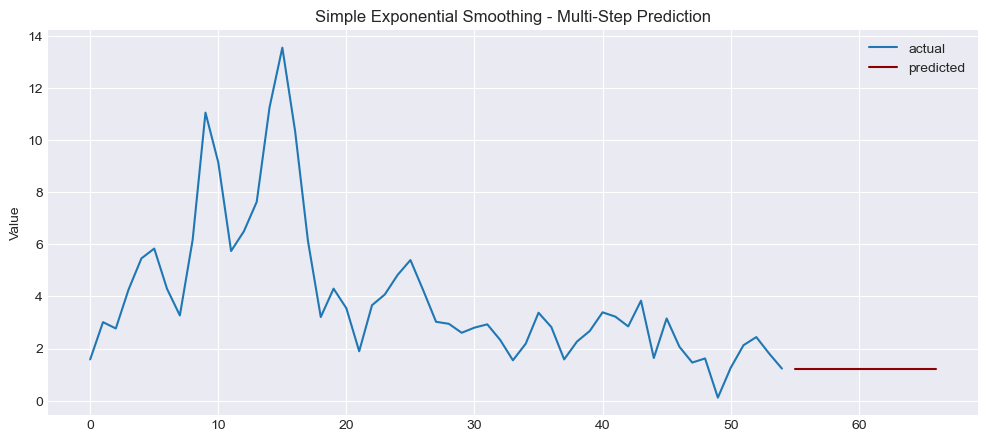

In [15]:
ses = SimpleExpSmoothing(cpi['Value'])
result = ses.fit(optimized=True)
actuals = cpi['Value'].values
predictions = result.predict(len(cpi), len(cpi)+11)

plt.figure(figsize=(12,5))
plt.plot(actuals, label='actual')
plt.plot(predictions, 'darkred', label='predicted')
plt.title('Simple Exponential Smoothing - Multi-Step Prediction')
plt.ylabel('Value')
plt.legend()
plt.show();

# Double Exponential Smoothing (a.k.a. Holt's Linear Trend)

In double exponential smoothing, the forecast function is no longer flat, but trending, and an $h$-step ahead forecast is equal to the last estimated level plus $h$ multiplied by the last estimated trend value. Alpha is responsible for the smoothing around the trend, and beta for smoothing of the trend itself. Double exponential smoothing with an additive trend is referred to as Holt’s linear trend model. Decomposition is used to obtain the intercept, level, and slope.

$$\begin{align*}
  \text{Forecast equation}&& \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} \\
  \text{Level equation}   && \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  \text{Trend equation}   && b_{t}    &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)b_{t-1},
\end{align*}$$

Again, if the parameters are left blank, then statsmodels will seek to optimize these parameters for us.

In [16]:
from statsmodels.tsa.holtwinters import Holt
import warnings
warnings.filterwarnings("ignore")

Now we check the error scores from a walkforward validation:

In [17]:
rmse_avg, mae_avg = predict_walkforward(cpi, 'Value', 11, Holt)
append_results('CPI', 'DES', rmse_avg, mae_avg)
results_df

,Dataset,Model,RMSE,MAE
1,CPI,SES,2.15,1.86
2,CPI,DES,16.5,15.45


### Damped Trend Method

Double exponential smoothing allows for the prediction of multiple points into the future, whereas SES does not. For longer-range forecast, the trend may continue on unrealistically, and for that reason, it can be helpful to include a damping coefficient, $\phi$.

$$\begin{align*}
  \hat{y}_{t+h|t} &= \ell_{t} + (\phi+\phi^2 + \dots + \phi^{h})b_{t} \\
  \ell_{t} &= \alpha y_{t} + (1 - \alpha)(\ell_{t-1} + \phi b_{t-1})\\
  b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 -\beta^*)\phi b_{t-1}.
\end{align*}$$

# Triple Exponential Smoothing

Though double exponential smoothing is able to handle a linear trend, it cannot account for seasonality. Triple exponential smoothing does, by having 3 smoothing equations and 3 parameters:
- the level $\ell$, with parameter $\alpha$
- the trend $b_t$, with parameter $\beta^*$
- the seasonal component $s_t$, with parameter $\gamma$

The additive method is preferred when the seasonal variations are roughly constant.

$$\begin{align*}
  \hat{y}_{t+h|t} &= \ell_{t} + hb_{t} + s_{t+h-m(k+1)} \\
  \ell_{t} &= \alpha(y_{t} - s_{t-m}) + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  b_{t} &= \beta^*(\ell_{t} - \ell_{t-1}) + (1 - \beta^*)b_{t-1}\\
  s_{t} &= \gamma (y_{t}-\ell_{t-1}-b_{t-1}) + (1-\gamma)s_{t-m},
\end{align*}$$

The multiplicative method is preferred when seasonal variations change proportionately to the level of the series.

$$\begin{align*}
  \hat{y}_{t+h|t} &= (\ell_{t} + hb_{t})s_{t+h-m(k+1)} \\
  \ell_{t} &= \alpha \frac{y_{t}}{s_{t-m}} + (1 - \alpha)(\ell_{t-1} + b_{t-1})\\
  b_{t} &= \beta^*(\ell_{t}-\ell_{t-1}) + (1 - \beta^*)b_{t-1}                \\
  s_{t} &= \gamma \frac{y_{t}}{(\ell_{t-1} + b_{t-1})} + (1 - \gamma)s_{t-m}.
\end{align*}$$

In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

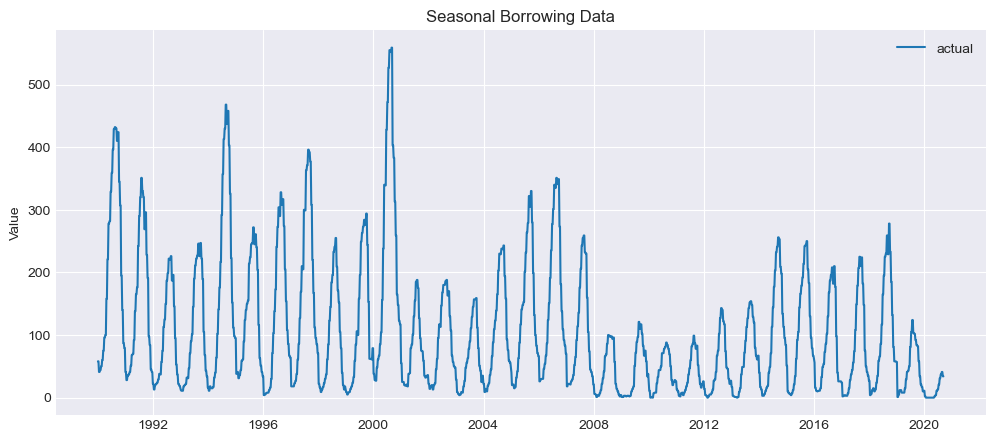

In [19]:
plt.figure(figsize=(12,5))
plt.plot(sborrow['Value'], label='actual')
plt.title('Seasonal Borrowing Data')
plt.ylabel('Value')
plt.legend()
plt.show();

In [20]:
es = ExponentialSmoothing(sborrow['Value'])
result = es.fit(optimized=True)
result.params

{'smoothing_level': 0.9999999850988388,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 57.99929283334166,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [21]:
dataset = sborrow
field = 'Value'
ps = [26, 52, 104]

In [22]:
import warnings
warnings.filterwarnings("ignore")

for p in ps:
    
    n_train = p
    schedule = create_schedule(dataset, field, n_train*3)

    for i in range(0,len(schedule)):
        train_st_idx = schedule['train_st'][i]
        train_end_idx = schedule['train_end'][i]
        test_st_idx = schedule['test_st'][i]
        test_end_idx = schedule['test_end'][i]

        m = ExponentialSmoothing(dataset[field][train_st_idx:train_end_idx],
                                     trend='Additive',
                                     seasonal='add',  
                                     seasonal_periods=n_train)        

        result = m.fit()
        yhat = result.predict(test_st_idx,test_st_idx+n_train-1)
        yhat[yhat<0] = 0
        actuals = dataset[field][test_st_idx:test_end_idx+1].values
        actuals = actuals[-n_train:]
        rmse_result = rmse(yhat.values, actuals)
        mae_result = mean_absolute_error(yhat.values, actuals)
    print(str(p) + ' periods,', 'RMSE ' + str(round(rmse_result,2)), ', MAE ' + str(round(mae_result,2)))

26 periods, RMSE 15535.97 , MAE 15535.6
52 periods, RMSE 59.11 , MAE 45.35
104 periods, RMSE 107.28 , MAE 98.17


One could further grid-search the parameters.

### Multi-Step Prediction

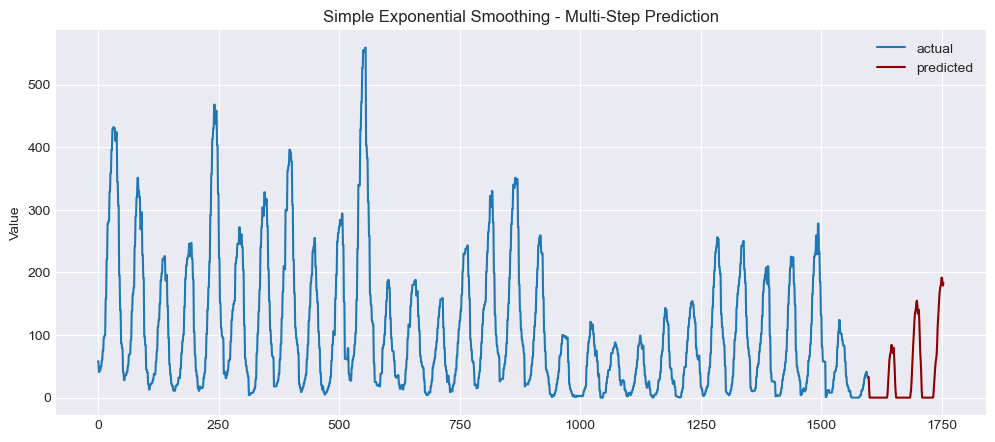

In [23]:
es = ExponentialSmoothing(sborrow['Value'], trend='additive',
                                     seasonal='additive',  
                                     seasonal_periods=n_train)        

result = es.fit(optimized=True)
actuals = sborrow['Value'].values
predictions = result.predict(len(sborrow), len(sborrow)+156)
predictions[predictions < 0] = 0

plt.figure(figsize=(12,5))
plt.plot(actuals, label='actual')
plt.plot(predictions, 'darkred', label='predicted')
plt.title('Simple Exponential Smoothing - Multi-Step Prediction')
plt.ylabel('Value')
plt.legend()
plt.show();

The next workbook is about autoregressive methods, and can be found <a href="https://github.com/pw598/Articles/blob/main/Forecasting%20III%20-%20Autoregressive%20Models.ipynb">here</a>.